# 02 — Storage Requirement & Capacity Check

**Question:** How much space does the client's stock need, and does it fit in the warehouse?

Converting stock to cubic metres is the easy part. But a warehouse doesn't run out of cubic metres — it runs out of **positions**. And in pharmaceutical storage, one rule drives the position count more than anything else:

> **One batch per pallet position.** Batches are never mixed on a pallet, so every batch can be traced, recalled and rotated by expiry date.

That means a batch of three cartons occupies a whole pallet position, exactly like a batch of three full pallets occupies three. This notebook measures how much space that rule costs — and what to do about it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA, OUT = Path("../data"), Path("../outputs")

pallet = pd.read_csv(DATA / "pallet_build.csv")
inv = pd.read_csv(DATA / "inventory_snapshot.csv", parse_dates=["expiry_date", "snapshot_date"])
print(f"{len(inv):,} batch rows | {len(pallet)} SKUs with a usable pallet build")

1,259 batch rows | 588 SKUs with a usable pallet build


## 1. Join stock to pallet builds

Stock for the 12 SKUs with missing dimensions or weights (Notebook 1) can't be sized until the client supplies measurements. It's set aside and reported rather than guessed.

In [2]:
stock = inv.merge(pallet, on="sku", how="left", indicator=True)
unsized = stock[stock._merge == "left_only"]
stock = stock[stock._merge == "both"].drop(columns="_merge").copy()

print(f"Sized: {len(stock):,} batch rows")
print(f"Awaiting client data: {len(unsized)} batch rows across {unsized.sku.nunique()} SKUs")

Sized: 1,234 batch rows
Awaiting client data: 25 batch rows across 12 SKUs


## 2. Convert stock to cases, CBM and pallets

- **Cases** = units ÷ units per case
- **CBM** = cases × case volume
- **Pallets** = cases ÷ cases per pallet — kept as a decimal, so 2.3 means two full pallets and a part pallet
- **Stock value** = units × unit cost

In [3]:
stock["cases"] = stock.qty_units / stock.units_per_case
stock["cbm"] = stock.cases * stock.case_cbm
stock["pallets"] = stock.cases / stock.cases_per_pallet
stock["value_nzd"] = stock.qty_units * stock.unit_cost_nzd

print(f"Total volume: {stock.cbm.sum():,.0f} CBM  |  Total value: NZ${stock.value_nzd.sum()/1e6:,.2f}M")
stock.groupby("stock_type")[["cbm", "value_nzd"]].sum().round(1)

Total volume: 2,344 CBM  |  Total value: NZ$72.37M


,cbm,value_nzd
stock_type,,
Damaged,1.4,23989.9
Expired,10.9,508066.8
FOC,6.9,231360.7
Saleable,2321.5,71529182.2
Sample,3.7,77048.4


## 3. The naive position count

If every batch goes into pallet racking, with the part pallet rounded up to a full position:

In [4]:
stock["positions_naive"] = np.ceil(stock.pallets)

naive = stock.groupby("storage_condition").agg(
    batches=("sku", "size"), cbm=("cbm", "sum"), positions=("positions_naive", "sum"))
naive["cbm_per_position"] = naive.cbm / naive.positions
naive.round(2)

,batches,cbm,positions,cbm_per_position
storage_condition,,,,
2-8C,92,94.32,181.0,0.52
Ambient,127,791.00,1508.0,0.52
Below 25C,1015,1459.16,2604.0,0.56


A full pallet holds about 0.87 CBM (Notebook 1). If positions are averaging far less than that, the racking is storing air. Where is it going?

In [5]:
bands = pd.cut(stock.cbm, [0, 0.1, 0.25, 0.5, 1, 2, 1000],
               labels=["≤0.1", "0.1–0.25", "0.25–0.5", "0.5–1", "1–2", ">2"])
by_size = stock.groupby(bands, observed=True).agg(
    batches=("sku", "size"), cbm=("cbm", "sum"), positions=("positions_naive", "sum"))
by_size["share_of_positions"] = by_size.positions / by_size.positions.sum()
by_size["share_of_cbm"] = by_size.cbm / by_size.cbm.sum()
by_size.round(3)

,batches,cbm,positions,share_of_positions,share_of_cbm
cbm,,,,,
≤0.1,385,13.669,385.0,0.090,0.006
0.1–0.25,185,30.712,185.0,0.043,0.013
0.25–0.5,140,48.421,142.0,0.033,0.021
0.5–1,148,105.219,193.0,0.045,0.045
1–2,135,190.970,326.0,0.076,0.081
>2,241,1955.495,3062.0,0.713,0.834


## 4. Zoning rules

Three rules, each standard practice in pharmaceutical warehousing:

| Rule | Zone | Why |
|---|---|---|
| Expired or damaged stock | **Quarantine** | Must be physically segregated from saleable stock and cannot be picked |
| Batch of 0.25 CBM or less | **Shelving bin** | A few cartons don't justify a full pallet position |
| Everything else | **Pallet racking** | One batch per position, part pallets rounded up |

In [6]:
SHELF_MAX_CBM = 0.25

quarantine = stock.stock_type.isin(["Expired", "Damaged"])
shelving = ~quarantine & (stock.cbm <= SHELF_MAX_CBM)

stock["zone"] = np.select([quarantine, shelving], ["Quarantine", "Shelving"], default="Pallet racking")
stock["positions"] = np.where(stock.zone == "Pallet racking", np.ceil(stock.pallets), 0)
stock["shelf_bins"] = np.where(stock.zone == "Shelving", 1, 0)

req = stock.groupby(["storage_condition", "zone"]).agg(
    batches=("sku", "size"), cbm=("cbm", "sum"),
    positions=("positions", "sum"), shelf_bins=("shelf_bins", "sum"))
req.round(1)

batches     cbm  positions  shelf_bins
storage_condition zone                                                  
2-8C              Pallet racking       44    90.5      133.0           0
                  Quarantine            5     0.7        0.0           0
                  Shelving             43     3.1        0.0          43
Ambient           Pallet racking       87   787.1     1467.0           0
                  Quarantine            6     1.3        0.0           0
                  Shelving             34     2.6        0.0          34
Below 25C         Pallet racking      518  1413.3     2102.0           0
                  Quarantine           49    10.3        0.0           0
                  Shelving            448    35.6        0.0         448

## 5. Capacity check

The warehouse's current layout. The temperature-controlled chamber is uniform pallet racking with **no shelving** — every location is a full-height pallet position.

| Area | Condition | Pallet positions | Shelf bins | Quarantine CBM |
|---|---|---|---|---|
| Chamber A | Below 25°C | 1,900 | 0 | — |
| Cold room | 2–8°C | 150 | 60 | — |
| Chamber B | Ambient | 1,600 | 0 | — |
| Quarantine cage | Any | — | — | 20 |

In [7]:
CAPACITY = pd.DataFrame({
    "storage_condition": ["Below 25C", "2-8C", "Ambient"],
    "area": ["Chamber A", "Cold room", "Chamber B"],
    "positions_available": [1900, 150, 1600],
    "bins_available": [0, 60, 0],
}).set_index("storage_condition")

need = stock[stock.zone != "Quarantine"].groupby("storage_condition").agg(
    positions_needed=("positions", "sum"), bins_needed=("shelf_bins", "sum"))

cap = CAPACITY.join(need)
# Where there is no shelving, small batches must take a pallet position instead
cap["positions_needed_today"] = cap.positions_needed + np.maximum(cap.bins_needed - cap.bins_available, 0)
cap["shortfall"] = np.maximum(cap.positions_needed_today - cap.positions_available, 0)
cap["utilisation"] = cap.positions_needed_today / cap.positions_available

quarantine_cbm = stock.loc[stock.zone == "Quarantine", "cbm"].sum()
print(f"Quarantine: {quarantine_cbm:.1f} CBM needed of 20 CBM available\n")
cap[["area", "positions_available", "positions_needed", "bins_needed",
     "positions_needed_today", "shortfall", "utilisation"]].round(2)

Quarantine: 12.3 CBM needed of 20 CBM available



,area,positions_available,positions_needed,bins_needed,positions_needed_today,shortfall,utilisation
storage_condition,,,,,,,
Below 25C,Chamber A,1900,2102.0,448,2550.0,650.0,1.34
2-8C,Cold room,150,133.0,43,133.0,0.0,0.89
Ambient,Chamber B,1600,1467.0,34,1501.0,0.0,0.94


## 6. Chamber A — the problem in one chart

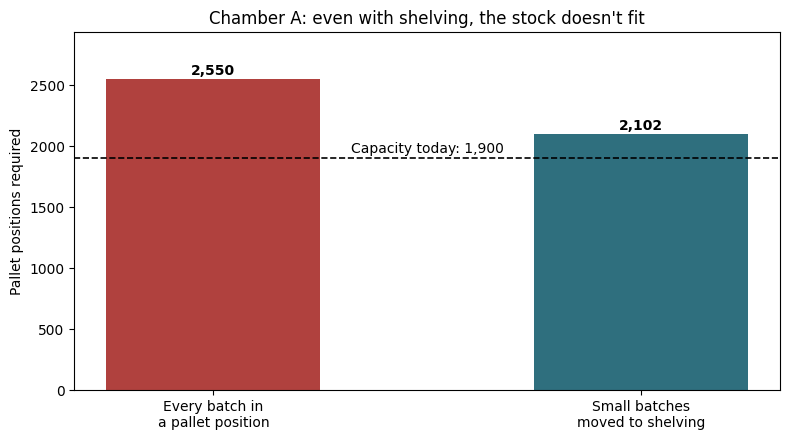

In [8]:
a = cap.loc["Below 25C"]
scenarios = pd.Series({
    "Every batch in\na pallet position": stock.loc[(stock.storage_condition == "Below 25C") & (stock.zone != "Quarantine"), "positions_naive"].sum(),
    "Small batches\nmoved to shelving": a.positions_needed,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(scenarios.index, scenarios.values, color=["#b0413e", "#2f6f7e"], width=0.5)
ax.axhline(a.positions_available, color="black", ls="--", lw=1.2)
ax.text(0.5, a.positions_available + 40, f"Capacity today: {a.positions_available:,.0f}", ha="center")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 30, f"{b.get_height():,.0f}", ha="center", fontweight="bold")
ax.set(title="Chamber A: even with shelving, the stock doesn't fit",
       ylabel="Pallet positions required", ylim=(0, scenarios.max() * 1.15))
plt.tight_layout()
plt.savefig(OUT / "02_chamber_a_requirement.png", dpi=150)
plt.show()

## 7. Stock health

Space isn't the only thing a mobilisation analysis surfaces. Stock that is expired, or saleable but close to expiry, costs rack space and represents a write-off risk the client should know about before it moves.

In [9]:
snap = stock.snapshot_date.iloc[0]
stock["months_to_expiry"] = (stock.expiry_date - snap).dt.days / 30.4

saleable = stock.stock_type.isin(["Saleable", "FOC"])
near = saleable & (stock.months_to_expiry < 6)

health = pd.DataFrame({
    "batches": [(stock.stock_type == "Expired").sum(), near.sum()],
    "value_nzd": [stock.loc[stock.stock_type == "Expired", "value_nzd"].sum(), stock.loc[near, "value_nzd"].sum()],
    "positions": [stock.loc[stock.stock_type == "Expired", "positions_naive"].sum(), stock.loc[near, "positions"].sum()],
}, index=["Already expired", "Expiring within 6 months"])
health.round(0)

,batches,value_nzd,positions
Already expired,41,508067.0,46.0
Expiring within 6 months,110,6931111.0,314.0


## 8. Save

In [10]:
stock.to_csv(DATA / "storage_requirement.csv", index=False)

with pd.ExcelWriter(OUT / "02_storage_requirement.xlsx") as xl:
    cap.to_excel(xl, sheet_name="Capacity check")
    req.to_excel(xl, sheet_name="Requirement by zone")
    by_size.to_excel(xl, sheet_name="Batch size profile")
    health.to_excel(xl, sheet_name="Stock health")
    unsized[["sku", "batch", "stock_type", "qty_units"]].to_excel(xl, sheet_name="Awaiting client data", index=False)

print("Saved storage_requirement.csv and 02_storage_requirement.xlsx")

Saved storage_requirement.csv and 02_storage_requirement.xlsx


## Findings

- **2,344 CBM of stock worth NZ$72.4M** across 1,234 sized batches. A further 25 batches (12 SKUs) can't be sized until the client supplies carton measurements.
- **Positions, not volume, are the constraint.** If every batch takes its own pallet position, the client needs 4,293 positions averaging just 0.55 CBM each — against 0.87 CBM for a full pallet.
- **570 small batches (0.25 CBM or less) would take 13% of all positions while holding under 2% of the volume.** They belong in shelving, not pallet racking.
- **Chamber A doesn't fit.** With no shelving, it needs 2,550 positions against 1,900 available — 650 short. Even with small batches moved to 448 shelving bins, it still needs 2,102 positions: 202 short (11%). And Chamber A has no shelving today, so creating it means changing the racking — the subject of Notebook 4.
- **The cold room and Chamber B fit**, at 89% and 94% utilisation. Chamber B is tight, leaving little room for growth.
- **Stock health flag for the client:** NZ$0.51M already expired across 41 batches, and NZ$6.93M of saleable stock expiring within six months across 110 batches — worth resolving before transfer rather than paying to move and store it.